In [7]:
import numpy as np
import pandas as pd
import joblib
import json
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)

# Load Data
X_test = pd.read_csv(
    r"C:\Users\Monay\Code\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\X_test.csv",
    index_col="Date",
    parse_dates=True
)

y_test = pd.read_csv(
    r"C:\Users\Monay\Code\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\y_test.csv",
    index_col="Date",
    parse_dates=True
)

# Load Scaler
scaler = joblib.load(r"C:\Users\Monay\Code\Machine Learning\Projects\intel-daily-stock-price-prediction\models\scaler.joblib")

# Load Model
model = joblib.load(r"C:\Users\Monay\Code\Machine Learning\Projects\intel-daily-stock-price-prediction\models\linear_regression_eval.pkl")

# Converting DataFrame into Series
y_test = y_test.squeeze()

# Scaling
X_test_scaled = scaler.transform(X_test)

pred = model.predict(X_test_scaled)

In [8]:
# Metrics Evaluation
# Directory
output_dir = r"C:\Users\Monay\Code\Machine Learning\Projects\intel-daily-stock-price-prediction\outputs\predictions"
os.makedirs(output_dir, exist_ok=True)

# Structure Metrics Into Dictionary
metrics_data = {
    "model_coefficients": model.coef_[0].tolist(),
    "intercept": float(model.intercept_),
    "mae": float(mean_absolute_error(y_test, pred)),
    "mse": float(mean_squared_error(y_test, pred)),
    "r2_score": float(r2_score(y_test, pred))
}

# Save to a JSON file
file_path = os.path.join(output_dir, "metrics.json")
with open(file_path, "w", encoding="utf-8") as f:
    json.dump(metrics_data, f, indent=4)

print("Metrics JSON file has been successfully saved.")

Metrics JSON file has been successfully saved.


In [9]:
# Actual vs Predicted Values Into CSV File
results = pd.DataFrame(
    {"Actual Values": y_test, "Predicted Values": pred}, index=y_test.index
)

# File Path
file_path = os.path.join(output_dir, "predictions_vs_actual.csv")

# 4. Save to CSV
results.to_csv(file_path, index=True)

print("Predictions vs Actual CSV file has been successfully saved.")

Predictions vs Actual CSV file has been successfully saved.


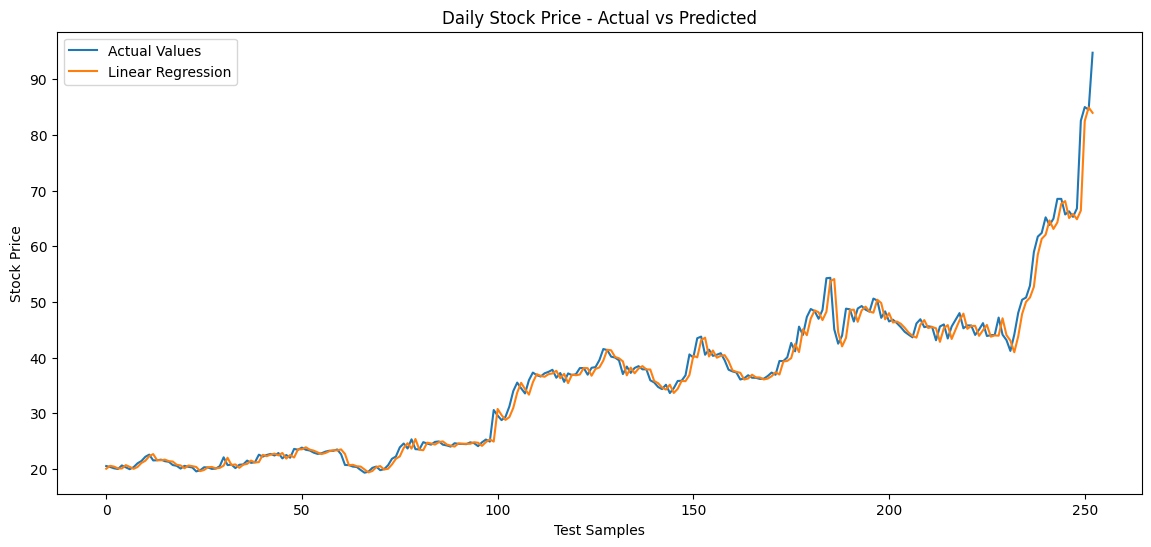

In [14]:
# Stock Price Graph (Actual vs Predicted)
# Plot
plt.figure(figsize=(14,6))

# Actual values
plt.plot(y_test.values, label='Actual Values')

# Linear Regression predictions
plt.plot(pred, label='Linear Regression')

# Labels and title
plt.title('Daily Stock Price - Actual vs Predicted')
plt.xlabel('Test Samples')
plt.ylabel('Stock Price')

# Legend
plt.legend()

# Save plot
plt.savefig(
    r"C:\Users\Monay\Code\Machine Learning\Projects\intel-daily-stock-price-prediction\outputs\charts\actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

# Show plot
plt.show()

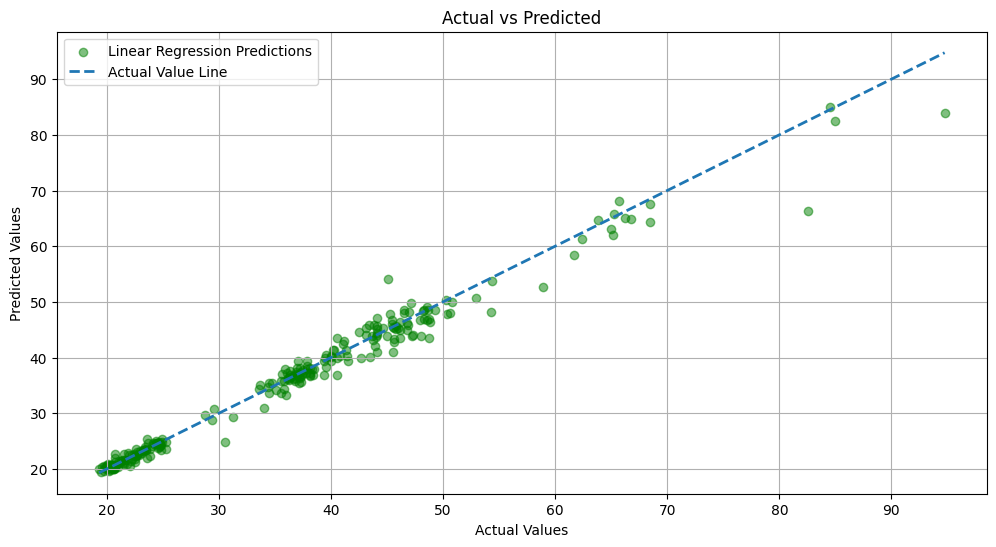

In [15]:
# Actual Value Line vs Linear Regression Predictions
# Create figure
plt.figure(figsize=(12,6))

# Scatter plots
plt.scatter(y_test, pred, label='Linear Regression Predictions', alpha=0.5, c='green')

# Perfect prediction line (Actual = Predicted)
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    label='Actual Value Line'
)

# Labels
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')

# Legend
plt.legend()

# Grid
plt.grid(True)

# Save plot
plt.savefig(
    r"C:\Users\Monay\Code\Machine Learning\Projects\intel-daily-stock-price-prediction\outputs\charts\linear_regression_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

# Show plot
plt.show()